# <center><u><b>Coupon Recoommendation</b></u></center>

## <i>Problem Statment</i>:
This data was collected via a survey on the Ecom website Mechanical Turk. The survey describes different driving scenarios including the user’s destination, current time, weather, passenger, coupon attributes, user attributes, and contextual attributes, and then asks the user whether he/she will accept the coupon or not.


## <i>Data Disctionary<i>:
1. Gender: Female, Male
2. Age: 21, 46, 26, 31, 41, 50plus, 36, below21
3. Marital Status: Unmarried partner, Single, Married partner, Divorced, Widowed
4. has_Children: 1: has children, 0: No children
5. Education: Some colleges — no degree, bachelor’s degree, Associates degree, High School Graduate, Graduate degree (Master or Doctorate), Some High School
6. Occupation: Traveller’s occupation 
7. Income: income of the travele
8.  Car: Description of vehicle driven by the traveller9. Bar: how many times does the traveler go to a bar every month
9.   Coffee House: how many times does the user go to a coffeehouse every month?
10. Carry Away: how many times does the user get takeaway food every month?
11. RestaurantLessThan20: how many times does the user go to a restaurant with an average expense per person of less than $20 every month?
12. Restaurant20To50: how many times does the user go to a restaurant with an average expense per person of $20 — $50 every month
13. Destination: destination of travele
14.  Passenger: who are the passengers in the car 
15. Weather: weather when the user is driving (Sunny, Rainy, Snow
16. . Temperature: temperature in Fahrenheit when the user is driving 
17. Cupon: Type of Cu
18. Expiration: Validity of Cupon
19. toCoupon_GEQ5min: driving distance to the restaurant/cafe/bar for using the coupon is greater than 5 minutes (0,1)
20. toCoupon_GEQ15min: driving distance to the restaurant/cafe/bar for using the coupon is greater than 15 minutes (0,1)
21. toCoupon_GEQ25min: driving distance to the restaurant/cafe/bar for using the coupon is greater than 25 minutes (0,1)
22. direction_same: whether the restaurant/cafe/bar is in the same direction as the traveler’s current destination (0,1)
23. direction_opp: whether the restaurant/cafe/bar is in the opposite direction as the user’s current destination (0,1)
23. Accept(Y/N?)- Target column( whether user will accept the coupon or not?)
pon



<hr>

In [4]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report,ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, roc_curve, roc_auc_score

import joblib

#ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

# Data cleaning

In [6]:
#import data
df = pd.read_csv('../DS_DATA.csv')

#data dimensions
df.shape

(12684, 25)

In [7]:
#sample data
pd.set_option('display.max_columns',None)
df.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,No Urgent Place,Alone,Sunny,55,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


In [8]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Accept(Y/N?)'],
      dtype='object')

In [9]:
#check duplicates
# print('Data have ',df[df.duplicated()].shape[0],' duplicate rows.')
print('Data have ',df.duplicated().sum(),' duplicate rows.')

Data have  291  duplicate rows.


In [10]:
#Remove duplicated data
df.drop_duplicates(inplace=True)

#after removing duplicates
print('Data have ',df.duplicated().sum(),' duplicate rows.')

Data have  0  duplicate rows.


In [11]:
#check datatypes

print(pd.concat([df.dtypes,df.head(3).T],axis=1))


                           0                         0  \
destination           object           No Urgent Place   
passanger             object                     Alone   
weather               object                     Sunny   
temperature            int64                        55   
coupon                object           Restaurant(<20)   
expiration            object                        1d   
gender                object                    Female   
age                   object                        21   
maritalStatus         object         Unmarried partner   
has_children           int64                         1   
education             object  Some college - no degree   
occupation            object                Unemployed   
income                object           $37500 - $49999   
car                   object                       NaN   
Bar                   object                     never   
CoffeeHouse           object                     never   
CarryAway     

In [12]:
for col in df.columns:
    print('----------------',col,'-----------------')
    print(df[col].unique())
    print(df[col].dtype)
    print() 

---------------- destination -----------------
['No Urgent Place' 'Home' 'Work']
object

---------------- passanger -----------------
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
object

---------------- weather -----------------
['Sunny' 'Rainy' 'Snowy']
object

---------------- temperature -----------------
[55 80 30]
int64

---------------- coupon -----------------
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
object

---------------- expiration -----------------
['1d' '2h']
object

---------------- gender -----------------
['Female' 'Male']
object

---------------- age -----------------
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
object

---------------- maritalStatus -----------------
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
object

---------------- has_children -----------------
[1 0]
int64

---------------- education -----------------
['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High 

### Observation: 
All columns have valid datatype

In [14]:
#check null vlaues
pd.concat([df.isnull().sum(),df.isna().sum()*100/df.shape[0]],axis=1)

,0,1
destination,0,0.000000
passanger,0,0.000000
weather,0,0.000000
temperature,0,0.000000
coupon,0,0.000000
expiration,0,0.000000
gender,0,0.000000
age,0,0.000000
maritalStatus,0,0.000000
has_children,0,0.000000


### Observations:
1. car column has 99.14% missing value => remove car column
2. Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50 columns have missing value ranging from 0.8 to 1.7% => Use mode for imputation 

In [16]:
del df['car']

In [17]:
#Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50
for col in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
   df[col].fillna(df[col].mode()[0],inplace=True)

In [18]:
#check null value after missing value treatment
df.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Accept(Y/N?)            0
dtype: int64

## EDA 

In [20]:
# !pip install ydata-profiling

In [21]:
import ydata_profiling as yp

# Generate the report
report = yp.ProfileReport(df)

In [22]:
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
#understand target variable
print(df['Accept(Y/N?)'].value_counts())
print()
print(df['Accept(Y/N?)'].value_counts(normalize=True)*100)

Accept(Y/N?)
1    7012
0    5381
Name: count, dtype: int64

Accept(Y/N?)
1    56.580328
0    43.419672
Name: proportion, dtype: float64


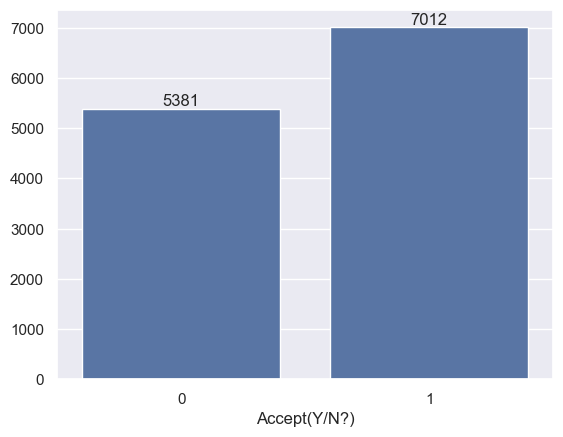

In [24]:
ax = sns.barplot(x=df['Accept(Y/N?)'].value_counts().index,y=df['Accept(Y/N?)'].value_counts().values)
ax.bar_label(ax.containers[0])
plt.show()

### Observation:
Target column does not have very bias data 

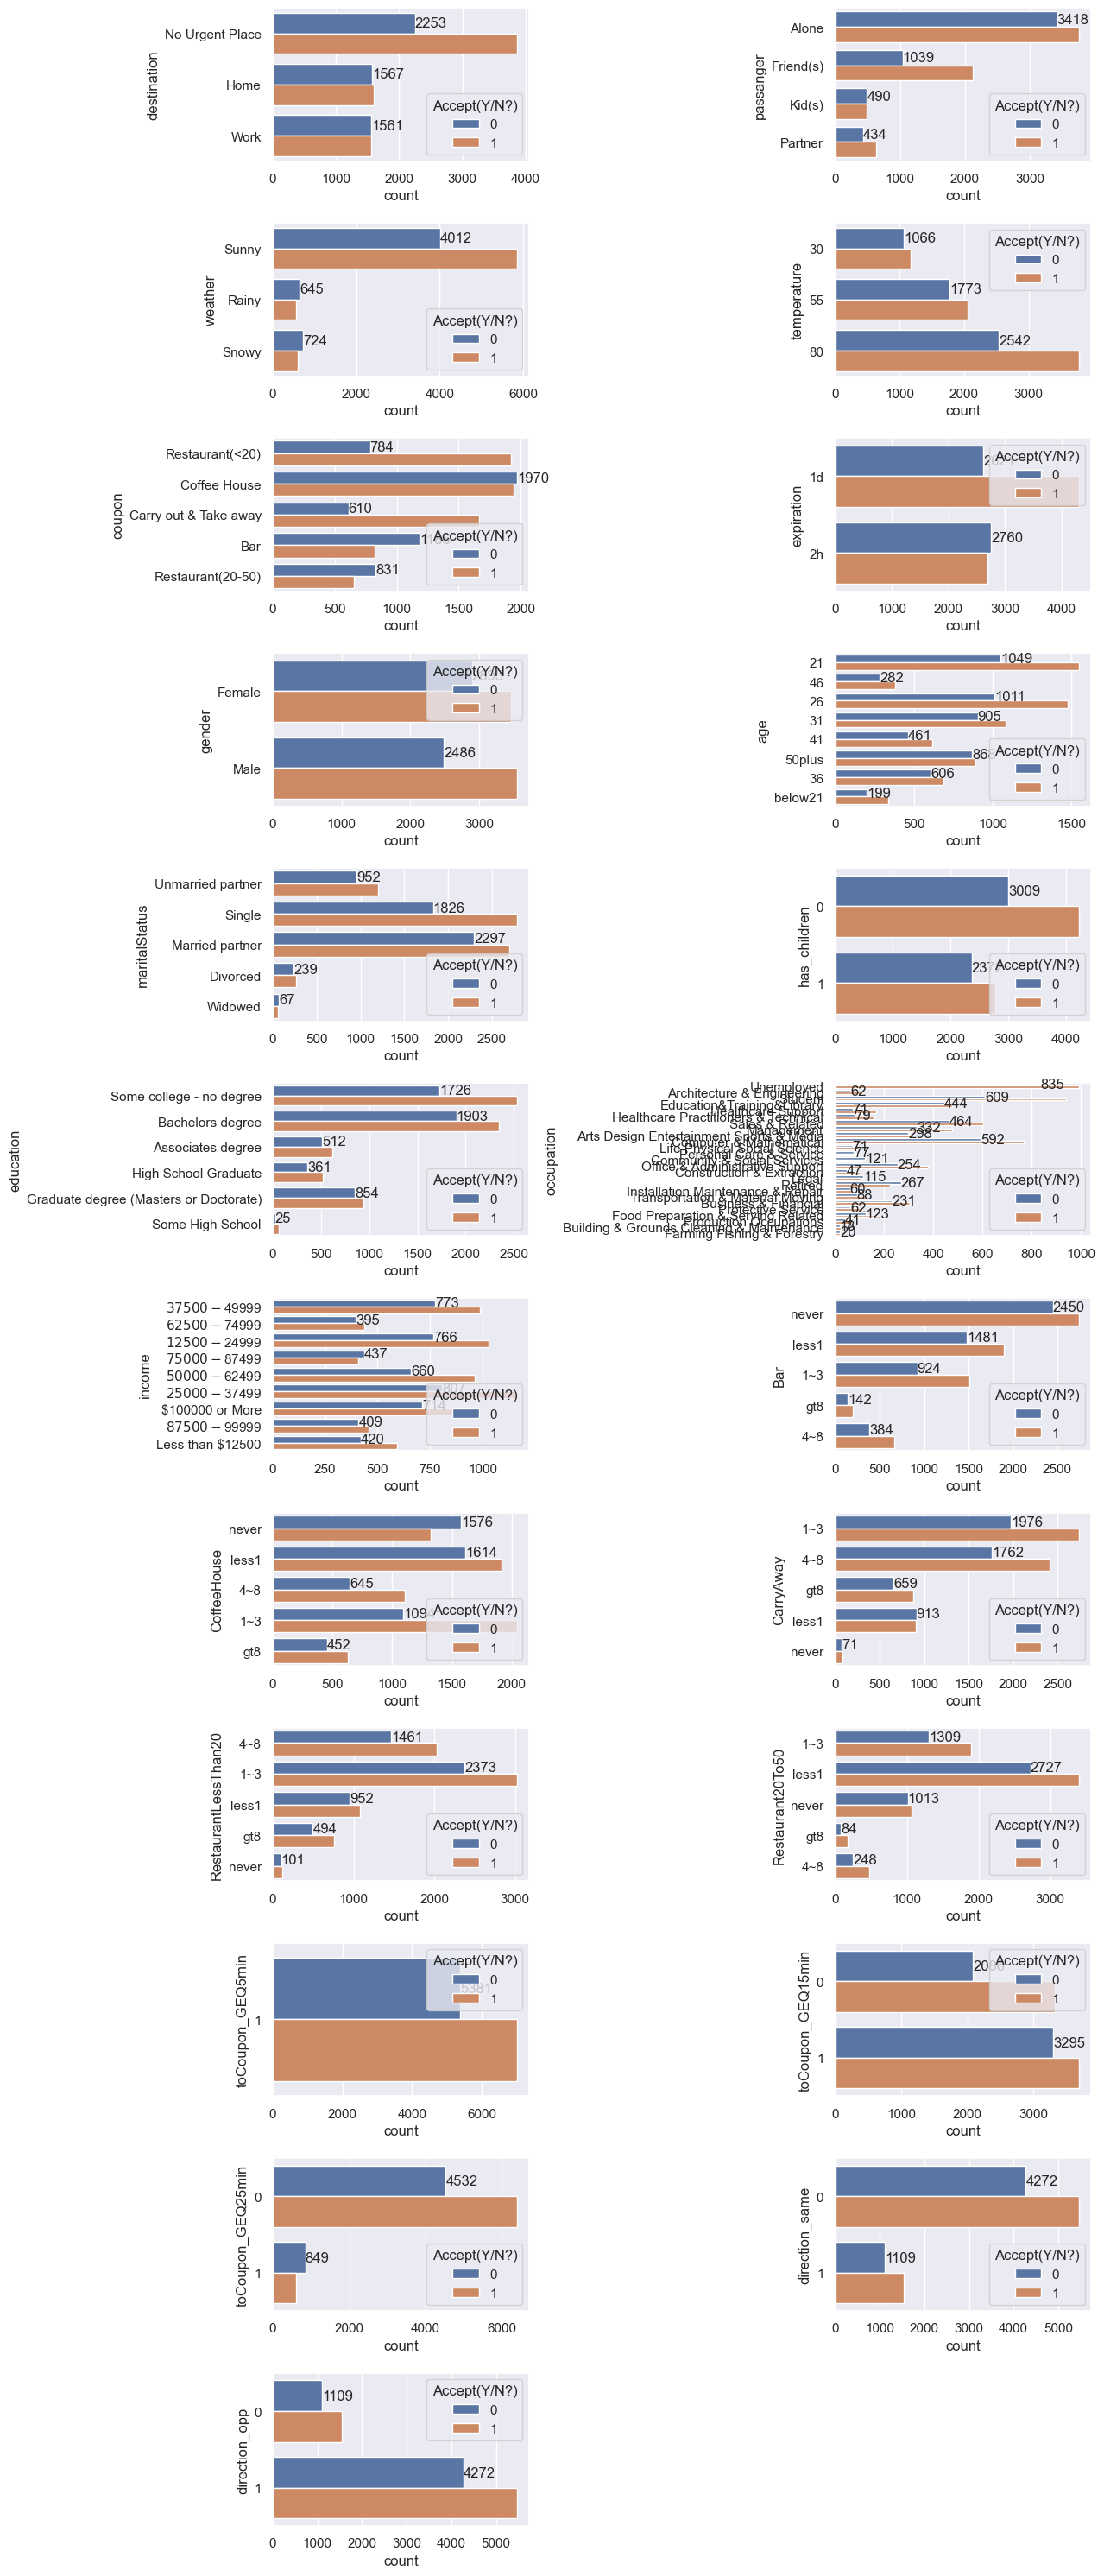

In [26]:
#understand categorical columns
plt.figure(figsize=(13,30))
i=1
for col in df.drop('Accept(Y/N?)',axis=1).columns:
    plt.subplot(12,2,i)
    ax=sns.countplot(data=df,y=col,hue='Accept(Y/N?)')
    ax.bar_label(ax.containers[0])
    i +=1

plt.tight_layout()
plt.savefig("plot.png")
plt.show()

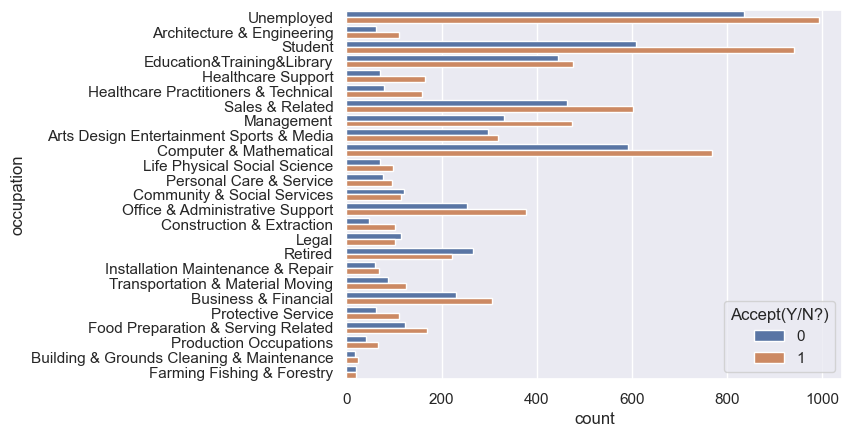

In [27]:
sns.countplot(data=df,y='occupation',hue='Accept(Y/N?)')
plt.show()

### Observations:
1. toCoupon_GEQ5min has constant value "1"	=> drop this column2. 
direction_opp is highlynegativelyl correlated witdirection_same => drop one of the column
3.
temperature is highly overall correlated wi weatherth  => will try with both or onofne the feature

In [29]:
# drop toCoupon_GEQ5min and direction_opp
df.drop(['toCoupon_GEQ5min','direction_opp'],axis=1,inplace=True)

In [30]:
df.shape

(12393, 22)

## Data Preprocessing and Feature engineering

In [32]:
#train test split

x = df.drop(columns=['Accept(Y/N?)'], axis=1)
y = df['Accept(Y/N?)']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

#data dimension of train and test
print('x_train: ',x_train.shape)
print('y_train: ',y_train.shape)
print('x_test: ',x_test.shape)
print('y_test: ',y_test.shape)

x_train:  (9914, 21)
y_train:  (9914,)
x_test:  (2479, 21)
y_test:  (2479,)


In [33]:
for col in df.columns:
    print('----------------',col,'-----------------')
    print(df[col].unique())
    print(df[col].dtype)
    print() 

---------------- destination -----------------
['No Urgent Place' 'Home' 'Work']
object

---------------- passanger -----------------
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
object

---------------- weather -----------------
['Sunny' 'Rainy' 'Snowy']
object

---------------- temperature -----------------
[55 80 30]
int64

---------------- coupon -----------------
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
object

---------------- expiration -----------------
['1d' '2h']
object

---------------- gender -----------------
['Female' 'Male']
object

---------------- age -----------------
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
object

---------------- maritalStatus -----------------
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
object

---------------- has_children -----------------
[1 0]
int64

---------------- education -----------------
['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High 

In [34]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'Accept(Y/N?)'],
      dtype='object')

### Observation:
1. 'age', 'education','income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50 => Ordinal Data
2. 'occupation', 'destination', 'passanger', 'weather', 'coupon',  'expiration', 'gender', 'maritalStatus => Nominal Data

#### Encoding''

In [36]:
# encoding of age columns
def age_cleaner(a):
    if a=='50plus':
        return '55'
    elif a=='below21':
        return '18'
    else:
        return a

x_train['age'] = x_train['age'].apply(age_cleaner).astype(int)
x_test['age'] = x_test['age'].apply(age_cleaner).astype(int)
x_train['age'].unique()

array([36, 31, 55, 41, 18, 21, 26, 46])

In [37]:
le = LabelEncoder()
x_train['occupation'] = le.fit_transform(x_train['occupation'])
x_test['occupation'] = le.transform(x_test['occupation'])

joblib.dump(le, 'occupation_label_encoder.pkl')
x_train['occupation'].unique()

array([ 7, 15, 20, 22,  1,  5,  9, 19, 13,  3,  6, 17, 24, 21, 11, 10, 16,
       23,  0, 18,  4,  8,  2, 14, 12])

In [38]:
def income_encoder(i):
    if i == 'Less than $12500':
        return 6250
    elif i == '$100000 or More':
        return 999999
    else:
        inc = i.split(' - ')
        return (int(inc[0][1:]) + int(inc[1][1:]))/2
        
x_train['income'] = x_train['income'].apply(income_encoder)
x_test['income'] = x_test['income'].apply(income_encoder)

x_train['income'].unique()

array([ 93749.5,  43749.5,  56249.5,  18749.5,   6250. ,  68749.5,
       999999. ,  31249.5,  81249.5])

In [39]:
# Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50

for col in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
    x_train[col] = x_train[col].map({'never':0,'less1':.5,'1~3':2,'4~8':6,'gt8':10})
    x_test[col] = x_test[col].map({'never':0,'less1':.5,'1~3':2,'4~8':6,'gt8':10})

x_train['Bar'].unique()

array([ 0.5,  0. ,  2. , 10. ,  6. ])

In [40]:
education_mapping = {
    'Some High School': 0,
    'High School Graduate': 1,
    'Some college - no degree': 2,
    'Associates degree': 3,
    'Bachelors degree': 4,
    'Graduate degree (Masters or Doctorate)': 5
}

x_train['education'] = x_train['education'].map(education_mapping)
x_test['education'] = x_test['education'].map(education_mapping)
x_train['education'].unique()

array([4, 5, 2, 1, 3, 0], dtype=int64)

In [41]:
x_train.shape

(9914, 21)

In [42]:
# Specify the categorical columns
nominal_cols = ['destination', 'passanger', 'weather', 'coupon', 'expiration', 'gender', 'maritalStatus']

# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' avoids dummy variable trap

# Fit and transform the categorical columns
encoded_data_x_train = encoder.fit_transform(x_train[nominal_cols])
encoded_data_x_test = encoder.transform(x_test[nominal_cols])

# Create DataFrame with encoded column names
encoded_data_x_train_df = pd.DataFrame(encoded_data_x_train, 
                          columns=encoder.get_feature_names_out(nominal_cols),
                          index=x_train.index)
encoded_data_x_test_df = pd.DataFrame(encoded_data_x_test, 
                          columns=encoder.get_feature_names_out(nominal_cols),
                          index=x_test.index)

# Concatenate encoded columns back to original data
x_train_encoded = pd.concat([x_train.drop(columns=nominal_cols), encoded_data_x_train_df], axis=1)
x_test_encoded = pd.concat([x_test.drop(columns=nominal_cols), encoded_data_x_test_df], axis=1)


# Check result
print(x_train_encoded.head())


      temperature  age  has_children  education  occupation   income  Bar  \
1425           55   36             1          4           7  93749.5  0.5   
5884           80   31             1          5          15  93749.5  0.0   
1482           80   55             1          2          20  43749.5  0.0   
1960           80   41             1          5           7  56249.5  0.5   
4454           80   18             0          2          22  18749.5  0.5   

      CoffeeHouse  CarryAway  RestaurantLessThan20  Restaurant20To50  \
1425         10.0        6.0                   2.0               0.5   
5884          0.0        6.0                  10.0               6.0   
1482          2.0        0.5                   2.0               2.0   
1960          6.0        6.0                   2.0               0.5   
4454         10.0        6.0                   2.0               0.5   

      toCoupon_GEQ15min  toCoupon_GEQ25min  direction_same  \
1425                  1                  0

In [43]:
x_train_encoded.shape

(9914, 31)

In [44]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(x_train_encoded, y_train)

chi2_results = pd.DataFrame({
    'Feature': x_train_encoded.columns,
    'Chi2_Score': chi_scores,
    'p_value': p_values
}).sort_values(by='Chi2_Score', ascending=False)

print(chi2_results)

# Select features with p-value < 0.05
selected_features = chi2_results[chi2_results['p_value'] < 0.05]['Feature'].tolist()
print("Selected Features:", selected_features)

#keep only selected features in X
X_selected = x_train_encoded[selected_features]

                            Feature     Chi2_Score       p_value
5                            income  511891.964251  0.000000e+00
21     coupon_Carry out & Take away     216.871632  4.352934e-49
7                       CoffeeHouse     202.624701  5.585752e-46
24           coupon_Restaurant(<20)     184.229065  5.782312e-42
0                       temperature     175.534759  4.575411e-40
1                               age     141.204716  1.451369e-32
16              passanger_Friend(s)     112.299544  3.072063e-26
10                 Restaurant20To50     101.376153  7.607415e-24
12                toCoupon_GEQ25min      98.925488  2.621832e-23
25                    expiration_2h      91.034799  1.411675e-21
14      destination_No Urgent Place      85.465980  2.357225e-20
6                               Bar      73.821378  8.551543e-18
23         coupon_Restaurant(20-50)      71.704354  2.499803e-17
22              coupon_Coffee House      61.715632  3.968174e-15
19                    wea

In [45]:
X_selected.shape

(9914, 27)

In [46]:
x_train_selected = x_train_encoded[selected_features]
x_test_selected = x_test_encoded[selected_features]

In [47]:
#based on feature importance removing ['destination_Work','coupon_Restaurant(20-50)','maritalStatus_Married partner','weather_Sunny','toCoupon_GEQ25min','passanger_Kid(s)','weather_Snowy']

# x_train_selected.drop(['destination_Work','coupon_Restaurant(20-50)','maritalStatus_Married partner','weather_Sunny','toCoupon_GEQ25min','passanger_Kid(s)','weather_Snowy'],axis=1,inplace=True)
# x_test_selected.drop(['destination_Work','coupon_Restaurant(20-50)','maritalStatus_Married partner','weather_Sunny','toCoupon_GEQ25min','passanger_Kid(s)','weather_Snowy'],axis=1,inplace=True)


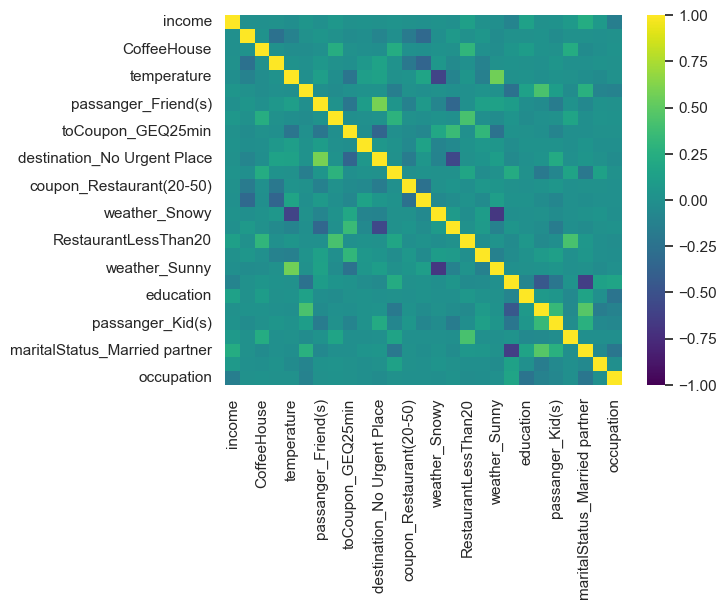

In [48]:
sns.heatmap(x_train_selected.corr(),vmin=-1,vmax=1,cmap='viridis')
plt.show()

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train_selected)
X_test_scaled = scaler.transform(x_test_selected)


In [50]:
# # Apply PCA for dimensionality reduction
# pca = PCA(n_components=0.95, random_state=42)  # keep 95% of variance
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

In [51]:
# print("Explained variance ratio:", pca.explained_variance_ratio_)
# print("Number of components:", pca.n_components_)


## Model Building

In [53]:
model_names = []
model_train_acc = []
model_test_acc = []
precision_acc = []
recall_acc = []
f1_acc = []
result_df = {}

In [54]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42,class_weight='balanced')
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('DecisionTreeClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('RandomForestClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('LogisticRegression')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [57]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('GaussianNB')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [58]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('LGBMClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

[LightGBM] [Info] Number of positive: 5609, number of negative: 4305
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 9914, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.565766 -> initscore=0.264595
[LightGBM] [Info] Start training from score 0.264595


In [59]:
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('XGBClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [60]:
result_df = {
    'Model_name' : model_names,
    'Train_acc' : model_train_acc,
    'Test_acc' : model_test_acc,
    'Precision_acc' : precision_acc,
    'Recall_acc' : recall_acc,
    'f1_score' : f1_acc
}
result_df = pd.DataFrame(result_df)

In [61]:
result_df

,Model_name,Train_acc,Test_acc,Precision_acc,Recall_acc,f1_score
0,DecisionTreeClassifier,0.988905,0.661960,0.706355,0.689237,0.697691
1,RandomForestClassifier,0.988905,0.741428,0.751984,0.810406,0.780103
2,LogisticRegression,0.665725,0.654699,0.718625,0.640770,0.677468
3,GaussianNB,0.639802,0.640984,0.675325,0.704205,0.689463
4,LGBMClassifier,0.809966,0.725696,0.738614,0.797577,0.766964
5,XGBClassifier,0.909522,0.749496,0.761714,0.811119,0.785640


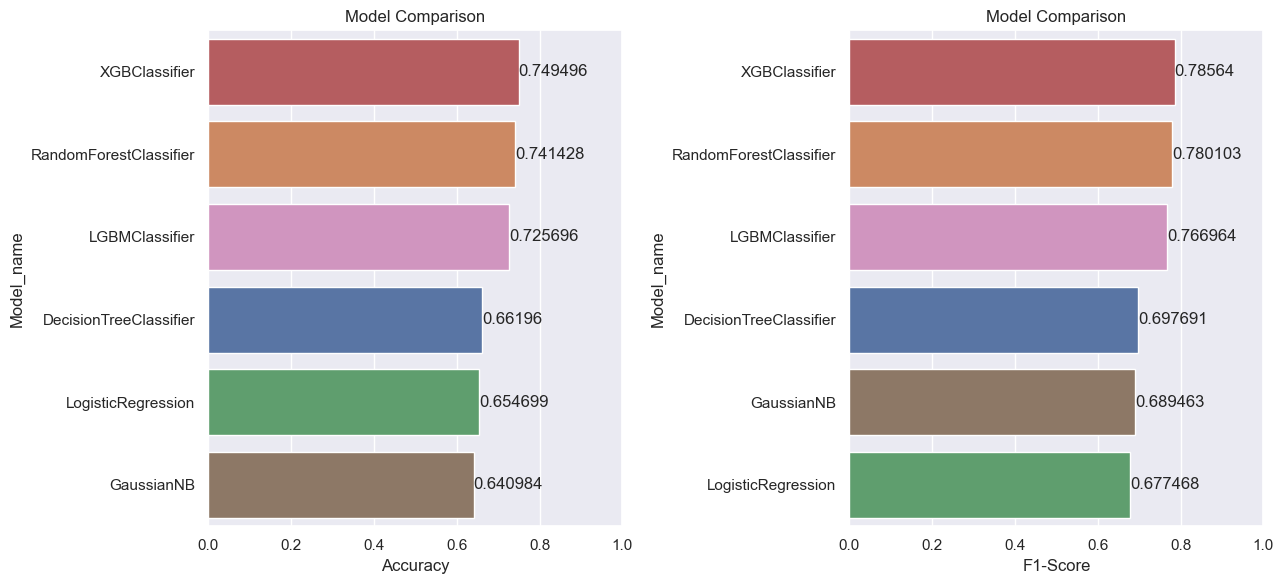

In [62]:
plt.figure(figsize=(13, 6))
custom_palette = {
    "DecisionTreeClassifier": "#4c72b0",          # deep blue
    "RandomForestClassifier": "#dd8452",          # orange
    "LogisticRegression": "#55a868",     # green
    "SVC": "#8172b3",     # purple
    "GaussianNB": "#937860", # brown
    "LGBMClassifier": "#da8bc3",       # pink
    "XGBClassifier": "#c44e52",           # red
}


plt.subplot(1,2,1)
ax = sns.barplot(x='Test_acc', y='Model_name',data=result_df.sort_values(by='Test_acc', ascending=False), palette=custom_palette)
for i in ax.containers:
    plt.bar_label(i)
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.xlim(0, 1)

plt.subplot(1,2,2)
ax = sns.barplot(x='f1_score', y='Model_name',data=result_df.sort_values(by='f1_score', ascending=False), palette=custom_palette)
for i in ax.containers:
    plt.bar_label(i)
plt.xlabel("F1-Score")
plt.title("Model Comparison")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.72      0.65      0.69      1076
           1       0.75      0.81      0.78      1403

    accuracy                           0.74      2479
   macro avg       0.74      0.73      0.73      2479
weighted avg       0.74      0.74      0.74      2479

Train Accuracy: 0.9889045793826912
Test Accuracy: 0.7414279951593384
precision: 0.751984126984127
recall: 0.8104062722736992
f1: 0.7801029159519726


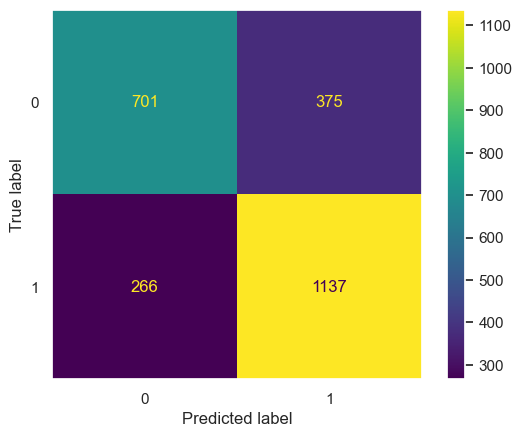

In [63]:
#RandomForest

rf = RandomForestClassifier(random_state=42, class_weight ='balanced')
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(classification_report(y_test, y_pred))
print('Train Accuracy:',rf.score(X_train_scaled, y_train))
print('Test Accuracy:',accuracy_score(y_test, y_pred))
print('precision:',precision)
print('recall:',recall)
print('f1:',f1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.grid(False)

### Hyperparameter tuning 

In [156]:
from sklearn.model_selection import GridSearchCV

# Base model
rf = RandomForestClassifier(random_state=42,class_weight ='balanced')

# Define parameter grid
param_grid = {
    'max_depth': [30, 40],
    'n_estimators': [300,400,500]
}


# Grid Search
grid = GridSearchCV(estimator=rf, 
                    param_grid=param_grid, 
                    scoring='recall',   
                    cv=5,
                    verbose=1,
                    n_jobs=-1)

grid.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [30, 40],
                         'n_estimators': [300, 400, 500]},
             scoring='recall', verbose=1)

In [157]:
print("Best Parameters:", grid.best_params_)

print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 40, 'n_estimators': 500}
Best Score: 0.8193969924357708


In [158]:
# Building the final model with the best parameter from grid search
best_parameters = grid.best_params_
final_model = RandomForestClassifier(**best_parameters, random_state=42,class_weight ='balanced')

# fit the data onto the final model
final_model.fit(X_train_scaled, y_train)

# model score
print('Training Score:', round(final_model.score(X_train_scaled, y_train)*100,2), '%')

Training Score: 98.89 %


In [159]:
# Testing our model
y_pred_final = final_model.predict(X_test_scaled)

# metrics
print('Testing Score', round(accuracy_score(y_test, y_pred_final)*100, 2), '%')

Testing Score 74.83 %


Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.65      0.69      1076
           1       0.76      0.82      0.79      1403

    accuracy                           0.75      2479
   macro avg       0.75      0.74      0.74      2479
weighted avg       0.75      0.75      0.75      2479



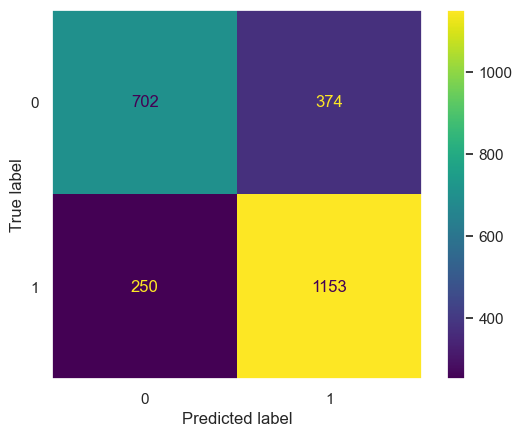

In [160]:
# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final))
plt.grid(False)

In [161]:
# Computing the AUC-ROC
fpr, tpr, thr = roc_curve(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_pred_final)
print('Area under the roc curve:', round(auc*100, 2), '%')

Area under the roc curve: 73.71 %


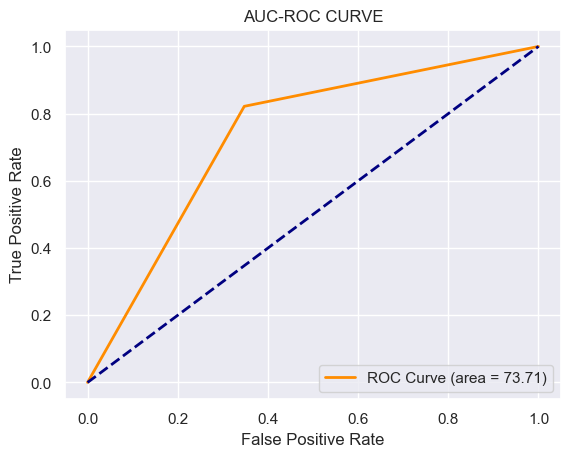

In [162]:
# Plotting the AUC ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {round(auc*100, 2)})')
plt.plot([0,1], [0,1], color='navy', lw=2, ls='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC CURVE')
plt.legend(loc=4)
plt.show()

In [163]:
imp = final_model.feature_importances_
col_names = x_train_selected.columns

fet_imp = pd.DataFrame({'feature':col_names,'importance':imp})
fet_imp = fet_imp.sort_values(by='importance',ascending=False)
fet_imp['importance(%)'] = 100* fet_imp['importance']/fet_imp['importance'].sum()
fet_imp['cummulative(%)'] = fet_imp['importance(%)'].cumsum()
fet_imp

,feature,importance,importance(%),cummulative(%)
26,occupation,0.090409,9.040912,9.040912
0,income,0.078862,7.886211,16.927123
2,CoffeeHouse,0.073671,7.367080,24.294203
5,age,0.068047,6.804727,31.098930
20,education,0.055281,5.528058,36.626987
11,Bar,0.053436,5.343573,41.970560
23,CarryAway,0.050621,5.062079,47.032639
7,Restaurant20To50,0.049283,4.928336,51.960975
16,RestaurantLessThan20,0.049193,4.919338,56.880313
4,temperature,0.040063,4.006344,60.886658


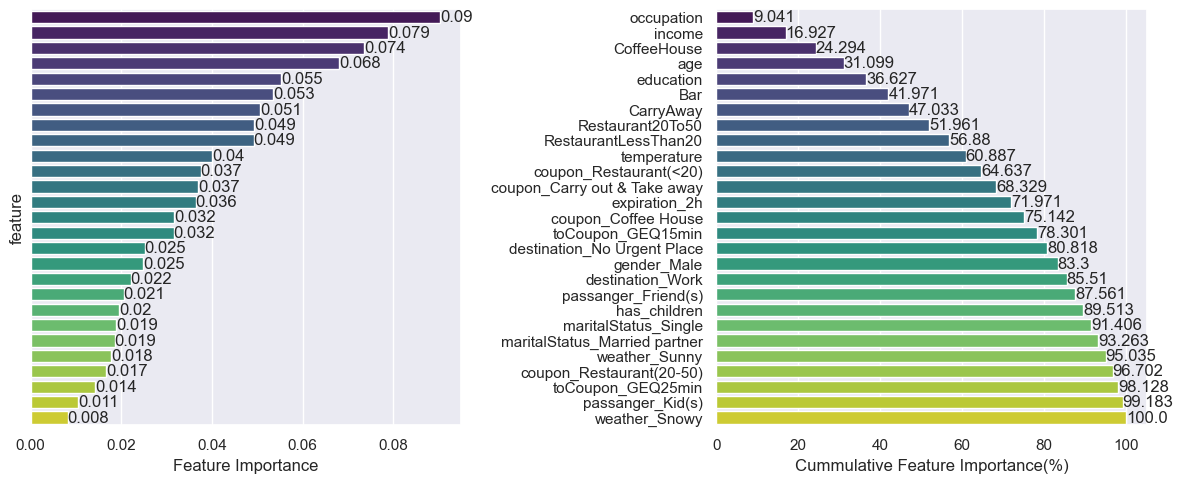

In [164]:
# Plotting Feature Importance
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
ax1=sns.barplot(x='importance', y='feature', data=fet_imp, palette='viridis')
for i in ax1.containers:
    plt.bar_label(i,fmt=lambda x: f'{round(x,3)}')
plt.yticks([])
plt.xlabel('Feature Importance')


plt.subplot(1,2,2)
ax2=sns.barplot(x='cummulative(%)', y='feature', data=fet_imp, palette='viridis')
for i in ax2.containers:
    plt.bar_label(i,fmt=lambda x: f'{round(x,3)}')
plt.ylabel('')
plt.xlabel('Cummulative Feature Importance(%)')

plt.tight_layout()
plt.show()